In [1]:
from test import *
from matplotlib import pyplot as plt

In [2]:
od = OceanDirectAPI()

In [3]:
device_count = od.find_usb_devices()
device_ids = od.get_device_ids()
print(device_count, device_ids)

1 [2]


In [4]:
device = od.open_device(device_ids[0])
serial_number = device.get_serial_number()
api_version = od.get_api_version_numbers()
print(device, serial_number, api_version)

<oceandirect.OceanDirectAPI.Spectrometer object at 0x000002D948E392B0> ST02611 (3, 1, 3)


In [9]:
device.set_electric_dark_correction_usage(False)
device.set_nonlinearity_correction_usage(True)
wavelengths = device.get_wavelengths()

In [66]:
num_spectra = 3
int_time_us=290000
device.set_integration_time(int_time_us)

In [67]:
averaged_spectrum = get_spectra_single(device, num_spectra)

Starting single spectra collection...
Averaging 3 single scans...
Single spectra collection finished.


1516


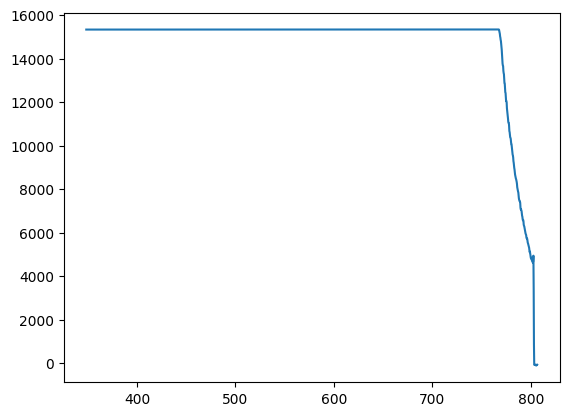

In [68]:
plt.plot(wavelengths, averaged_spectrum)
print(len(averaged_spectrum))

In [56]:
get_spectra_accelerate(device, num_spectra)

Starting accelerated spectra collection & simultaneous averaging...
Accelerated spectra collection & averaging finished.


In [70]:
max(averaged_spectrum)

15334.463216145834

In [18]:
wavelengths = device.get_wavelengths()

In [19]:
spectra = device.get_formatted_spectrum()

In [55]:
print(len(spectra))

1516


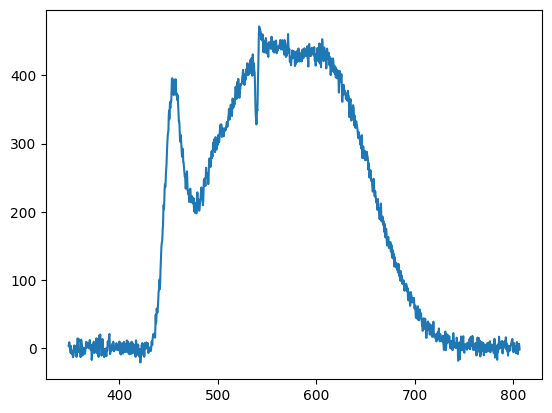

In [21]:
plt.plot(wavelengths,spectra)

In [70]:
del od